In [1]:
import pickle
import corner
import pandas as pd
import jax
import jax.numpy as jnp
import jax.scipy as jsp
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib as mpl
from model_new import *
# import arviz as az

/data/hz420-2/py312_jax_cuda/lib/python3.12/site-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.5.1 is installed, but it is not compatible with the installed jaxlib version 0.6.0, so it will not be used.
  warnings.warn(


<Figure size 640x480 with 0 Axes>

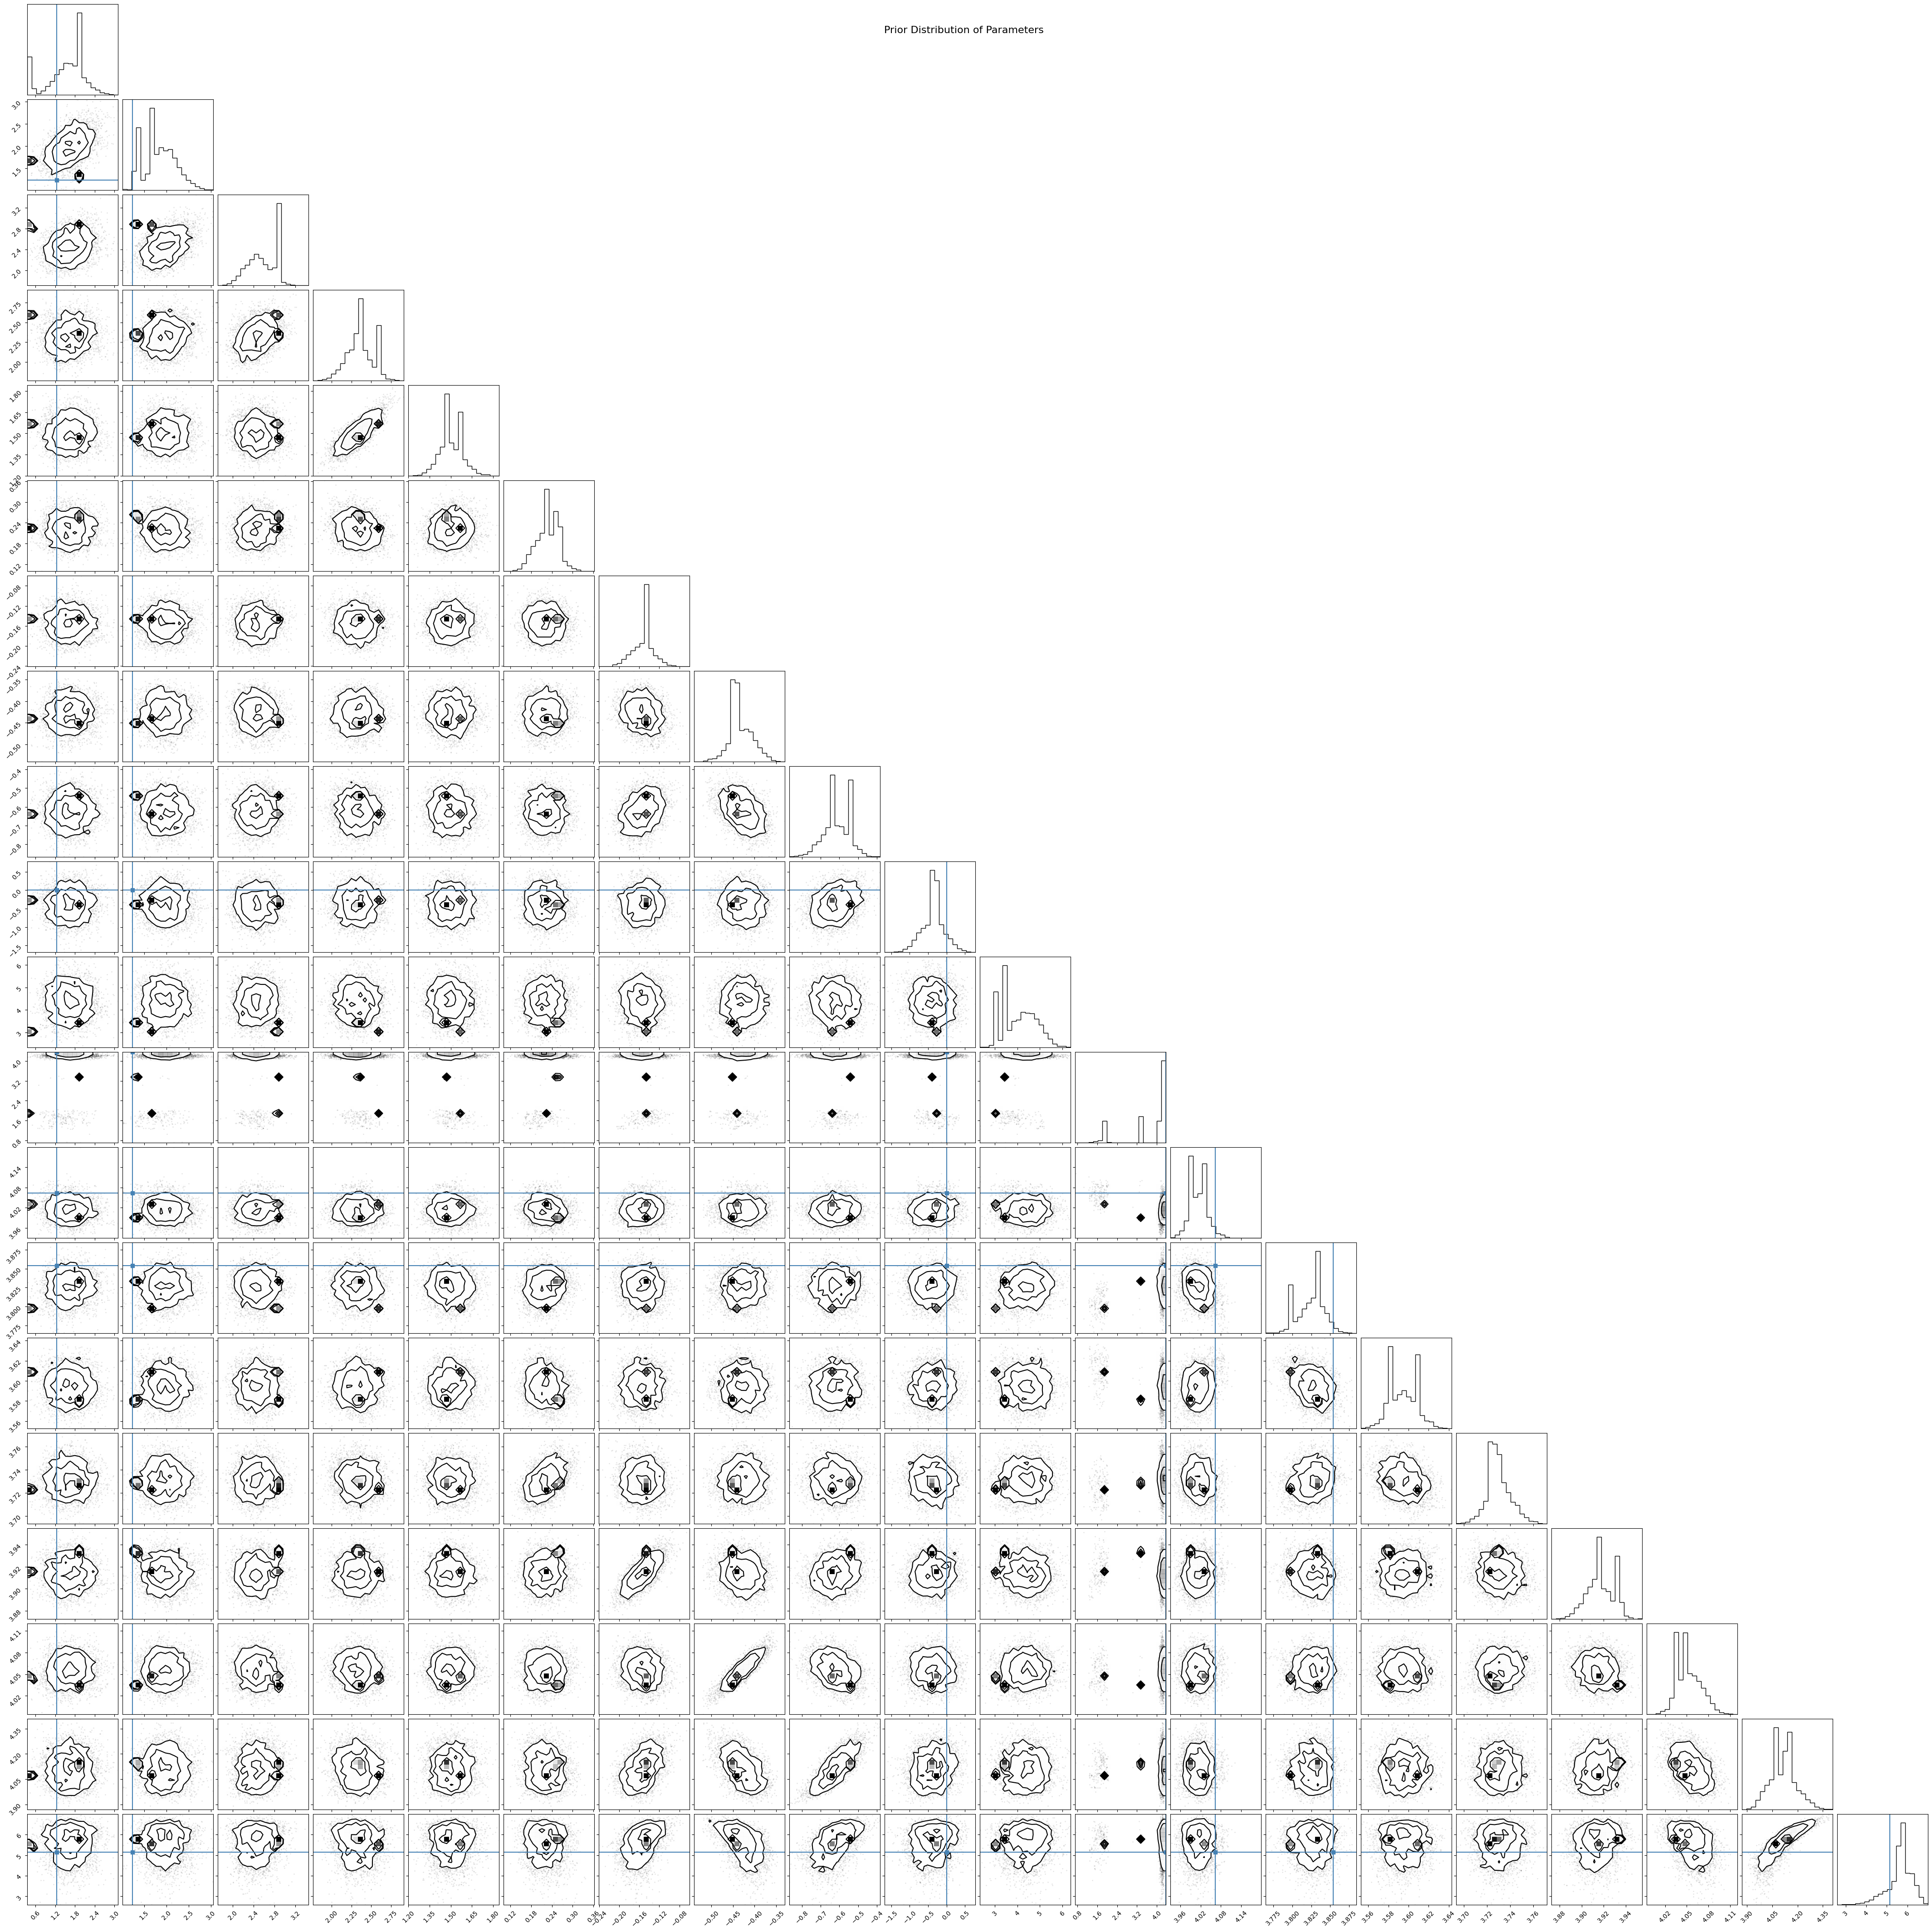

[ 1.2383736e+00  1.2383624e+00  1.2381361e+00  1.2336102e+00
  1.1499239e+00  5.0615895e-01  4.3122660e-02  2.2294684e-03
  1.1133528e-04 -1.0300213e-04            inf  4.3612227e+00
  4.0639391e+00  3.8541751e+00  3.7761078e+00  3.8552046e+00
  4.0579553e+00  4.3234844e+00  4.6051702e+00  5.1352773e+00]


In [106]:
age_pivot = np.array([0, 4, 8, 12])
sigmaLz_pivot = np.array([10, 200, 400, 1200]) # sigma_Lz at 6 Gyr
sigmaLz_gt_interp = sp.interpolate.interp1d(age_pivot, sigmaLz_pivot, kind='cubic', fill_value='extrapolate', bounds_error=False)
Rd_gt = Rd_evolution_jump(np.linspace(0,12,100), Rdmax = 3.45, Rdmin = 1, tau_Rd = 7.0, delta_tau_Rd = 1.0)
Rd_gt_interp = sp.interpolate.interp1d(np.linspace(0,12,100), Rd_gt, kind='cubic', fill_value='extrapolate', bounds_error=False)


Nknots = 10
file = f'/data/hz420-2/radial_migration_kernel/mock_sample/L_conditioned/results_{Nknots}knots_4.pkl'
with open(file, 'rb') as f:
    results = pickle.load(f)

ln_Rdisk = np.array(results['ln_Rdisk'])
ln_sigmaLz = np.array(results['ln_sigmaLz'])
import corner

ln_all = np.hstack([ln_Rdisk, ln_sigmaLz])
Nknots = ln_all.shape[1]//2
axu_knots = generate_aux_knots(Nknots=Nknots, age_max=12.)
truth = jnp.concatenate([jnp.log(Rd_gt_interp(axu_knots)), jnp.log(sigmaLz_gt_interp(axu_knots)/axu_knots)])
plt.figure()
corner.corner(ln_all,
              truths=truth,)
plt.suptitle('Prior Distribution of Parameters', fontsize=16)
plt.show()

print(truth)

In [ ]:
mcmc.print_summary()

100%|██████████| 4200/4200 [00:39<00:00, 106.43it/s]


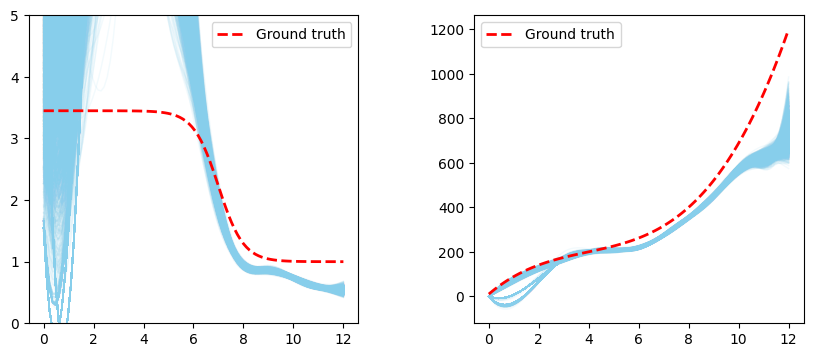

In [108]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [1, 1], 'wspace': 0.35})

ln_Rdisk = np.array(results['ln_Rdisk'])
ln_sigmaLz = np.array(results['ln_sigmaLz'])

for i in tqdm(range(0, len(ln_Rdisk))):
    ln_Rdisk_i = ln_Rdisk[i]
    ln_sigmaLz_i = ln_sigmaLz[i]
    Rdiskinterp = InterpolatedUnivariateSpline(axu_knots, np.exp(ln_Rdisk_i), k=3)
    sigmaLzinterp = InterpolatedUnivariateSpline(axu_knots, np.exp(ln_sigmaLz_i) * axu_knots, k=3)
    ax[0].plot(np.linspace(0,12,100), Rdiskinterp(np.linspace(0,12,100)), ls = '-', lw = 1, alpha = 0.1, color='skyblue', rasterized=True)
    ax[1].plot(np.linspace(0,12,100), sigmaLzinterp(np.linspace(0,12,100)), ls = '-', lw = 1, alpha = 0.1, color='skyblue', rasterized=True)

check_mock = True
print_ground_truth = check_mock
if print_ground_truth:
    Rdiskinterp = InterpolatedUnivariateSpline(aux_params['aux_knots'], np.exp(truth[:Nknots]), k=3)
    ax[0].plot(np.linspace(0,12,100), Rd_gt_interp(np.linspace(0,12,100)), label='Ground truth', color='red', ls='--', lw = 2)
    sigmaLzinterp = InterpolatedUnivariateSpline(aux_params['aux_knots'], np.exp(truth[Nknots:2*Nknots]), k=3)
    ax[1].plot(np.linspace(0,12,100), sigmaLz_gt_interp(np.linspace(0,12,100)), label='Ground truth', color='red', ls='--', lw = 2)

ax[0].legend()
ax[1].legend()
ax[0].set(ylim = [0,5])
plt.show()


In [73]:
path = '/data/hz420-2/'  # Path to the data directory

Vc0 = 240

df_mockdata = pd.read_csv(path+'radial_migration_kernel/mock_sample/L_conditioned/mock_data.csv')
F, logage, L = df_mockdata['MH'], df_mockdata['log_age'], df_mockdata['Lz']
sigma_F, sigma_logage, sigma_L = df_mockdata['sigma_MH'], df_mockdata['sigma_logage'], df_mockdata['sigma_Lz']

e_feh_median = np.amax([np.median(sigma_F), 0.01])
e_log10age_median = np.amax([np.median(sigma_logage), 0.02])
e_Lz_median = np.amax([np.median(sigma_L), 20])
print('Median errors: e_feh_median = ', e_feh_median,
      'e_log10age_median = ', e_log10age_median,
      'e_Lz_median = ', e_Lz_median)
feh_range = [-1.5,0.5]
logage_range = np.log10([0.3,12])
L_range = [9*Vc0,11*Vc0]
nfe = int((feh_range[1] - feh_range[0]) / e_feh_median)
nlogage = int((logage_range[1] - logage_range[0]) / e_log10age_median)
nL = int((L_range[1] - L_range[0]) / e_Lz_median)
print('Fe/H bins: ', nfe, 'bin size: ', (feh_range[1] - feh_range[0]) / nfe)
print('log10(age) bins: ', nlogage, 'bin size: ', (logage_range[1] - logage_range[0]) / nlogage)
print('Lz bins: ', nL, 'bin size: ', (L_range[1] - L_range[0]) / nL)

data_array = np.array([F, logage, L]).T
H, edges = np.histogramdd(data_array, bins=(nfe, nlogage, nL), range=[feh_range, logage_range, L_range])
print('H shape: ', H.shape, 'Total stars: ', H.sum(), 'Number of bins with H>1', (H>=1).sum())
# print(edges)
centers = [
    0.5*(edges[d][:-1] + edges[d][1:]) 
    for d in range(3)
]

ix, iy, iz = np.nonzero(H)  # each is a 1D array of the same length M

fe_centers     = centers[0][ix]
logage_centers = centers[1][iy]
L_centers      = centers[2][iz]
Nstars = H[ix, iy, iz]

# print(len(fe_centers), len(logage_centers), len(L_centers)
#       , len(H[ix, iy, iz]), H[ix, iy, iz].sum())
# plt.figure()
# cb = plt.scatter(10**logage_centers, fe_centers, c=H[ix, iy, iz], cmap='viridis', alpha=0.5)
# plt.colorbar(cb, label='Number of stars')
# plt.savefig('/data/hz420-2/radial_migration_kernel/mock_sample/L_conditioned/mock_data_binned.png', dpi=300)
# plt.show()


data_grid = {
    'MH': jnp.array(fe_centers),
    'log_age': jnp.array(logage_centers),
    'Lz': jnp.array(L_centers),
    'sigma_MH': jnp.array([e_feh_median] * len(fe_centers)) ,
    'sigma_logage': jnp.array([e_log10age_median] * len(logage_centers)),
    'sigma_Lz': jnp.array([e_Lz_median] * len(L_centers)),
}


Median errors: e_feh_median =  0.0599880939675056 e_log10age_median =  0.0300011326540007 e_Lz_median =  29.99291893087975
Fe/H bins:  33 bin size:  0.06060606060606061
log10(age) bins:  53 bin size:  0.03022754700618797
Lz bins:  16 bin size:  30.0
H shape:  (33, 53, 16) Total stars:  38715.0 Number of bins with H>1 6437


In [4]:

R_scale_for_sampling = 4
# F_centre_for_sampling, F_scale_for_sampling = -0.5,  0.5
F_centre_at_0, F_centre_at_12 = -0.1, -0.8
F_scale_at_0, F_scale_at_12 = 0.1, 0.7

data_generated = generate_sample_for_MC_integration_withprob(data_grid, R_scale_for_sampling = R_scale_for_sampling, 
                                                    F_centre_at_0=F_centre_at_0, F_centre_at_12=F_centre_at_12,
                                                    F_scale_at_0=F_scale_at_0, F_scale_at_12=F_scale_at_12,
                                                    N_sample = int(1e3)) 


data_generated['weights'] = jnp.array(Nstars)

Nknots = 10
# aux_params = {'R_scale_for_sampling':R_scale_for_sampling, 
#             'F_scale_for_sampling':F_scale_for_sampling, 
#             'F_centre_for_sampling':F_centre_for_sampling}  # Auxiliary parameters for the model
aux_params = {}
aux_params['aux_knots'] = generate_aux_knots(Nknots=Nknots, age_max=12.)


i = 286
params= {'ln_Rdisk': jnp.array(results['ln_Rdisk'][i]), 'ln_sigmaLz': jnp.array(results['ln_sigmaLz'][i])}
logP = logL_numpyro(data_generated, params, **aux_params)

print(jnp.sum(logP))

ln_Rdisk_gt = jnp.log(Rd_gt_interp(axu_knots))
ln_sigmaLz_gt = jnp.log(sigmaLz_gt_interp(axu_knots)/axu_knots)
ln_sigmaLz_gt = jnp.where(jnp.isfinite(ln_sigmaLz_gt), ln_sigmaLz_gt, 4.)  # Ensure non-negative values
params = {'ln_Rdisk': ln_Rdisk_gt, 'ln_sigmaLz': ln_sigmaLz_gt}
# path_to_dir = '/data/hz420-2/'
# read_file = path_to_dir+f'radial_migration_kernel/mock_sample/L_conditioned/minimization_result_{Nknots}knots_LzScaled.npy'
# minimiser_results = np.load(read_file)
# params = {
#     'ln_Rdisk': jnp.array(minimiser_results[:Nknots]),
#     'ln_sigmaLz': jnp.array(minimiser_results[Nknots:2*Nknots]),
# }
logP = logL_numpyro(data_generated, params, **aux_params)

print(jnp.sum(logP))

NameError: name 'results' is not defined

In [62]:
@jax.jit
def logL_numpyro(data, params, aux_knots):

    time_start = time.perf_counter()

    F_sample_num = data['F_sample_num']
    F_sample_denom = data['F_sample_denom']
    L0_sample_num = data['L0_sample_num']
    L0_sample_denom = data['L0_sample_denom']
    age_sample_num = data['age_sample_num']
    age_sample_denom = data['age_sample_denom']
    L_sample_num = data['L_sample_num']
    L_sample_denom = data['L_sample_denom']
    logP_L0_num = data['logP_L_num']
    logP_L0_denom = data['logP_L_denom']
    logP_F_denom = data['logP_F_denom']
    weights = data['weights']

    N_sample = L_sample_denom.shape[0]
    N_star = L_sample_denom.shape[1]

    ln_sigmaLz_knots_knots = params['ln_sigmaLz']
    ln_Rdisk_knots_knots = params['ln_Rdisk']

    sigmaLz_knots = jnp.exp(ln_sigmaLz_knots_knots) * aux_knots
    Rdisk_knots = jnp.exp(ln_Rdisk_knots_knots)
    Lcentre_knots = Rdisk_knots * Vc0

    Lcentre_func =  InterpolatedUnivariateSpline(aux_knots, Lcentre_knots, k=3)
    sigmaLz_func = InterpolatedUnivariateSpline(aux_knots, sigmaLz_knots, k=3)

    #### numerator section ####
    _logage_sample_num = jnp.log10(age_sample_num)
    _logage_sample_num_avg = jnp.mean(_logage_sample_num, axis=0)
    _age_sample_num = 10 ** jnp.repeat(_logage_sample_num_avg[None, :], N_sample, axis=0)
    Lcentre_sample = Lcentre_func(_age_sample_num)
    sigmaLz_sample = sigmaLz_func(_age_sample_num)
    sigmaLz_sample = jnp.where(sigmaLz_sample<20, 20, sigmaLz_sample)  # Ensure non-negative values
    # Lcentre_sample = Lcentre_func(age_sample_num)
    # sigmaLz_sample = sigmaLz_func(age_sample_num)

    logP_L_given_age_L0 = kernel_SB15_log(L_sample_num, L0_sample_num, Lcentre_sample, sigmaLz_sample)
    logP_F_given_age_L0 = f_MH0_log(F_sample_num, age_sample_num, L0_sample_num, tol = 1e-2)
    logP_L0_given_age = fL0_log(L0_sample_num, Lcentre_sample)

    log_num = logP_L_given_age_L0 + logP_F_given_age_L0 + logP_L0_given_age - logP_L0_num
    log_num_val = jsp.special.logsumexp(log_num, axis=0) - jnp.log(N_sample)

    #### denominator section ####
    _logage_sample_denom = jnp.log10(age_sample_denom)
    _logage_sample_denom_avg = jnp.mean(_logage_sample_denom, axis=0)
    _age_sample_denom = 10 ** jnp.repeat(_logage_sample_denom_avg[None, :], N_sample, axis=0)
    Lcentre_sample = Lcentre_func(_age_sample_denom)
    sigmaLz_sample = sigmaLz_func(_age_sample_denom)
    sigmaLz_sample = jnp.where(sigmaLz_sample<20, 20, sigmaLz_sample)  # Ensure non-negative values
    # Lcentre_sample = Lcentre_func(age_sample_denom)
    # sigmaLz_sample = sigmaLz_func(age_sample_denom)

    logP_L_given_age_L0 = kernel_SB15_log(L_sample_denom, L0_sample_denom, Lcentre_sample, sigmaLz_sample)
    logP_F_given_age_L0 = f_MH0_log(F_sample_denom, age_sample_denom, L0_sample_denom, tol = 1e-2)
    logP_L0_given_age = fL0_log(L0_sample_denom, Lcentre_sample)

    log_denom = logP_L_given_age_L0 + logP_F_given_age_L0 + logP_L0_given_age - logP_L0_denom - logP_F_denom
    log_denom_val = jsp.special.logsumexp(log_denom, axis=0) - jnp.log(N_sample)

    logL = (log_num_val - log_denom_val) * (weights)

    time_end = time.perf_counter()

    # jax.debug.print("param = {y}, log_p = {x}, time = {z}", x=jnp.sum(logL), y=params, z = (time_end - time_start))

    return logL

  0%|          | 0/10 [00:00<?, ?it/s]

lnL: 17254.233012019784
lnL: 17253.945455642264
lnL: 17253.576811158327
lnL: 17253.124518886223
lnL: 17252.59553604361
lnL: 17252.00414566257
lnL: 17251.363483069825
lnL: 17250.67179898186
lnL: 17249.893531971255
lnL: 

 10%|█         | 1/10 [00:06<00:57,  6.44s/it]

17248.92363074927
lnL: 15734.031102853805
lnL: 17046.917113137384
lnL: 17166.623628330188
lnL: 17209.641887386897
lnL: 17231.929785699947
lnL: 17245.078817172744
lnL: 17253.13495121863
lnL: 17257.71267543497
lnL: 17258.989508024744
lnL: 

 20%|██        | 2/10 [00:12<00:51,  6.41s/it]

...

 90%|█████████ | 9/10 [00:57<00:06,  6.39s/it]

3819.1555722946337
lnL: 17248.342495211877
lnL: 17249.23628133885
lnL: 17250.543948069535
lnL: 17252.4489482394
lnL: 17255.205466716616
lnL: 17259.150711213406
lnL: 17264.693292362474
lnL: 17272.219657279315
lnL: 17281.746474630687
lnL: 

100%|██████████| 10/10 [01:04<00:00,  6.40s/it]


17291.78085177097


100%|██████████| 10/10 [01:04<00:00,  6.48s/it]


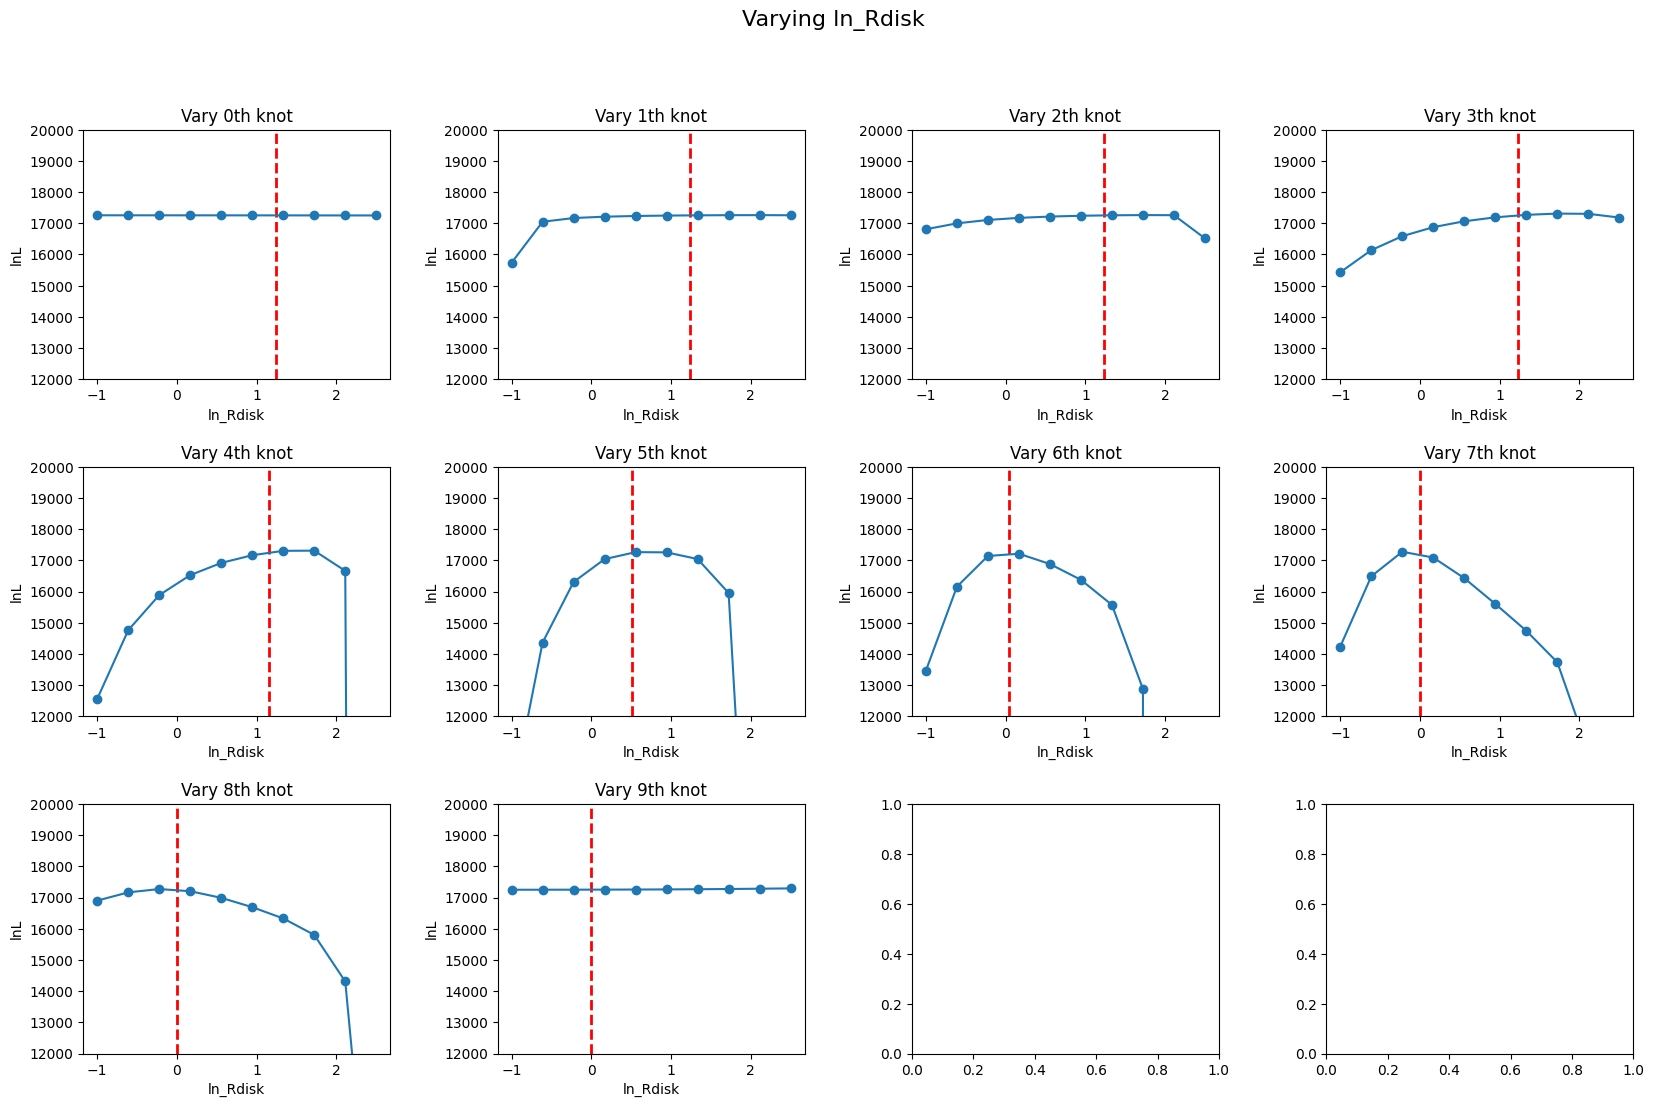

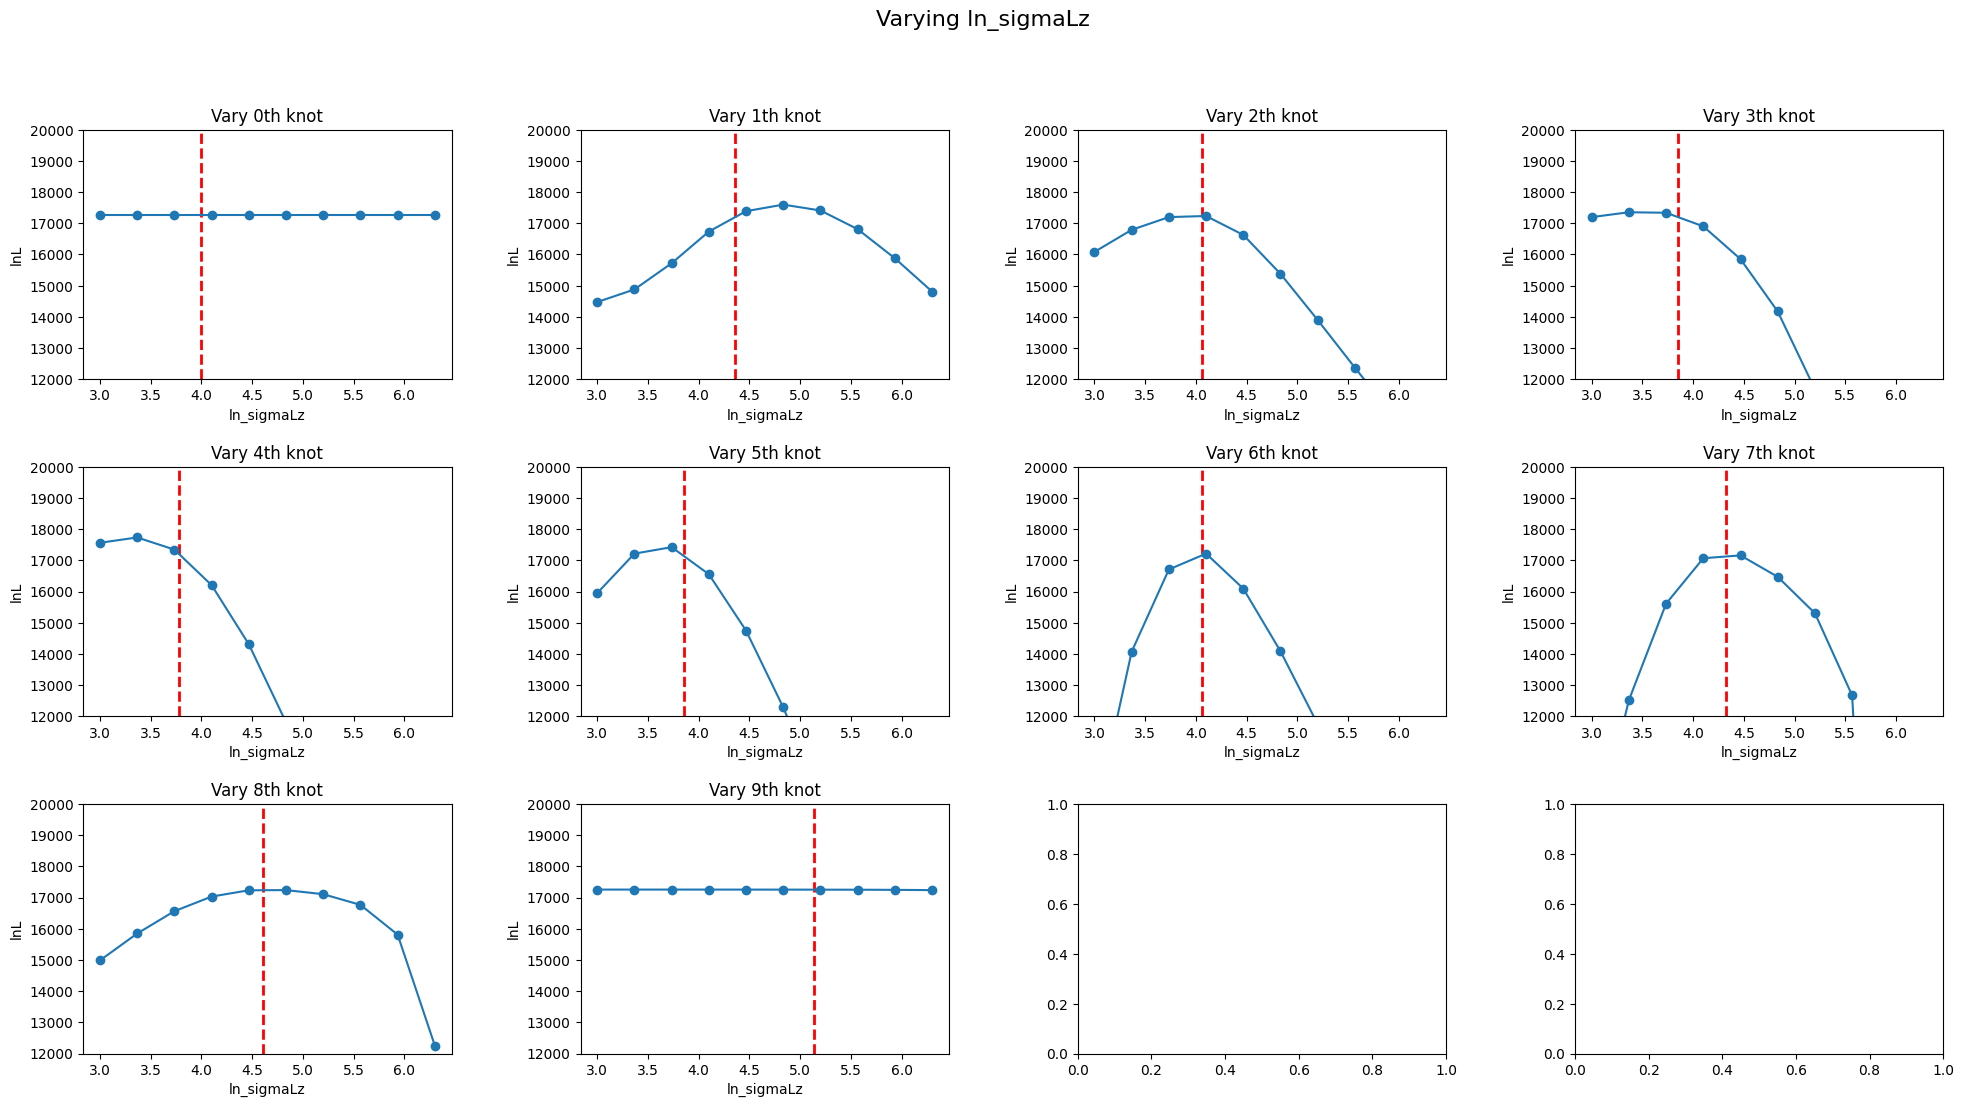

In [74]:
R_scale_for_sampling = 4
# F_centre_for_sampling, F_scale_for_sampling = -0.5,  0.5
F_centre_at_0, F_centre_at_12 = -0.1, -0.7
F_scale_at_0, F_scale_at_12 = 0.1, 0.6

data_generated = generate_sample_for_MC_integration_withprob(data_grid, R_scale_for_sampling = R_scale_for_sampling, 
                                                    F_centre_at_0=F_centre_at_0, F_centre_at_12=F_centre_at_12,
                                                    F_scale_at_0=F_scale_at_0, F_scale_at_12=F_scale_at_12,
                                                    N_sample = int(1e3)) 


data_generated['weights'] = jnp.array(Nstars)



age_pivot = np.array([0, 4, 8, 12])
sigmaLz_pivot = np.array([10, 200, 400, 1200]) # sigma_Lz at 6 Gyr
sigmaLz_gt_interp = sp.interpolate.interp1d(age_pivot, sigmaLz_pivot, kind='cubic', fill_value='extrapolate', bounds_error=False)
Rd_gt = Rd_evolution_jump(np.linspace(0,12,100), Rdmax = 3.45, Rdmin = 1, tau_Rd = 7.0, delta_tau_Rd = 1.0)
Rd_gt_interp = sp.interpolate.interp1d(np.linspace(0,12,100), Rd_gt, kind='cubic', fill_value='extrapolate', bounds_error=False)

Nknots = 10
axu_knots = generate_aux_knots(Nknots=Nknots, age_max=12.)
aux_params = {}
aux_params['aux_knots'] = axu_knots
truth = jnp.concatenate([jnp.log(Rd_gt_interp(axu_knots)), jnp.log(sigmaLz_gt_interp(axu_knots)/axu_knots)])

ln_Rdisc_plotrange = [-1,2.5]
ln_sigmaLz_plotrange = [3., 6.3]
ln_Rdisc_plotgrid = np.linspace(ln_Rdisc_plotrange[0], ln_Rdisc_plotrange[1], 10)
ln_sigmaLz_plotgrid = np.linspace(ln_sigmaLz_plotrange[0], ln_sigmaLz_plotrange[1], 10)

nrow = Nknots//4 + 1
fig, ax = plt.subplots(nrow, 4, figsize=(5*4, 4*nrow), gridspec_kw={'wspace': 0.35, 'hspace': 0.35})
ax = ax.flatten()
fig.suptitle('Varying ln_Rdisk', fontsize=16)
for i in tqdm(range (0, Nknots)):
    # path_to_dir = '/data/hz420-2/'
    # read_file = path_to_dir+f'radial_migration_kernel/mock_sample/L_conditioned/minimization_result_{Nknots}knots_LzScaled.npy'
    # minimiser_results = np.load(read_file)
    ln_Rdisk_i = np.log(Rd_gt_interp(axu_knots)) # minimiser_results[:Nknots]
    ln_sigmaLz_i = np.log(sigmaLz_gt_interp(axu_knots)/axu_knots) # minimiser_results[Nknots:2*Nknots]
    ln_sigmaLz_i = np.where(np.isfinite(ln_sigmaLz_i), ln_sigmaLz_i, 4.)  # Ensure non-negative values

    ax[i].axvline(ln_Rdisk_i[i], color='red', ls='--', lw=2, label='Ground truth')

    lnL_ls = []
    for j in range (0, len(ln_Rdisc_plotgrid)):
        ln_Rdisk_i[i] = ln_Rdisc_plotgrid[j]
        params = {
            'ln_Rdisk': jnp.array(ln_Rdisk_i),
            'ln_sigmaLz': jnp.array(ln_sigmaLz_i),
        }
        # print('params:', params)
        logP = logL_numpyro(data_generated, params, **aux_params)

        lnL_ls.append(jnp.sum(logP))
        print('lnL:', jnp.sum(logP))

    ax[i].plot(ln_Rdisc_plotgrid, lnL_ls, marker ='o')
    ax[i].set_xlabel('ln_Rdisk')
    ax[i].set_ylabel('lnL')
    ax[i].set_title(f'Vary {i}th knot')
    ax[i].set_ylim([1.2e4,2e4])

nrow = Nknots//4 + 1
fig, ax = plt.subplots(nrow, 4, figsize=(6*4, 4*nrow), gridspec_kw={'wspace': 0.35, 'hspace': 0.35})
ax = ax.flatten()
fig.suptitle('Varying ln_sigmaLz', fontsize=16)
for i in tqdm(range (0, Nknots)):
    ln_Rdisk_i = np.log(Rd_gt_interp(axu_knots)) # minimiser_results[:Nknots]
    ln_sigmaLz_i = np.log(sigmaLz_gt_interp(axu_knots) / axu_knots) # minimiser_results[Nknots:2*Nknots]
    ln_sigmaLz_i = np.where(np.isfinite(ln_sigmaLz_i), ln_sigmaLz_i, 4.)  # Ensure non-negative values

    ax[i].axvline(ln_sigmaLz_i[i], color='red', ls='--', lw=2, label='Ground truth')

    lnL_ls = []
    for j in range (0, len(ln_sigmaLz_plotgrid)):
        ln_sigmaLz_i[i] = ln_sigmaLz_plotgrid[j]
        params = {
            'ln_Rdisk': jnp.array(ln_Rdisk_i),
            'ln_sigmaLz': jnp.array(ln_sigmaLz_i),
        }
        logP = logL_numpyro(data_generated, params, **aux_params)

        lnL_ls.append(jnp.sum(logP))
    
    ax[i].plot(ln_sigmaLz_plotgrid, lnL_ls, marker ='o')
    ax[i].set_xlabel('ln_sigmaLz')
    ax[i].set_ylabel('lnL')
    ax[i].set_title(f'Vary {i}th knot')
    ax[i].set_ylim([1.2e4,2e4])

plt.show()


In [72]:
for i in tqdm(range (0, N_knots)):
    ln_Rdisk_i = np.log(Rd_gt_interp(axu_knots)) # minimiser_results[:Nknots]
    ln_sigmaLz_i = np.log(sigmaLz_gt_interp(axu_knots) / axu_knots) # minimiser_results[Nknots:2*Nknots]
    ln_sigmaLz_i = np.where(np.isfinite(ln_sigmaLz_i), ln_sigmaLz_i, 4.)  # Ensure non-negative values

    ax[i].axvline(ln_sigmaLz_i[i], color='red', ls='--', lw=2, label='Ground truth')

    params = {
    'ln_Rdisk': jnp.array(ln_Rdisk_i),
    'ln_sigmaLz': jnp.array(ln_sigmaLz_i),
    }
    logP = logL_numpyro(data_generated, params, **aux_params)
    print('val:', jnp.sum(logP))

    lnL_ls = []
    for j in range (0, len(ln_sigmaLz_plotgrid)):
        ln_sigmaLz_i[i] = ln_sigmaLz_plotgrid[j]
        params = {
            'ln_Rdisk': jnp.array(ln_Rdisk_i),
            'ln_sigmaLz': jnp.array(ln_sigmaLz_i),
        }
        print('params:', i, j, params)
        logP = logL_numpyro(data_generated, params, **aux_params)
        print('val:', jnp.sum(logP))

  0%|          | 0/10 [00:00<?, ?it/s]

val: 14673.814
params: 0 0 {'ln_Rdisk': Array([ 1.23837364e+00,  1.23836243e+00,  1.23813605e+00,  1.23361003e+00,
        1.14992392e+00,  5.06159008e-01,  4.31226753e-02,  2.22947448e-03,
        1.11335277e-04, -1.02985694e-04], dtype=float32), 'ln_sigmaLz': Array([3.       , 4.3612227, 4.063939 , 3.854175 , 3.7761078, 3.8552046,
       4.0579557, 4.3234844, 4.6051702, 5.1352773], dtype=float32)}
val: 14673.814
params: 0 1 {'ln_Rdisk': Array([ 1.23837364e+00,  1.23836243e+00,  1.23813605e+00,  1.23361003e+00,
        1.14992392e+00,  5.06159008e-01,  4.31226753e-02,  2.22947448e-03,
        1.11335277e-04, -1.02985694e-04], dtype=float32), 'ln_sigmaLz': Array([3.3666666, 4.3612227, 4.063939 , 3.854175 , 3.7761078, 3.8552046,
       4.0579557, 4.3234844, 4.6051702, 5.1352773], dtype=float32)}
val: 14673.814
params: 0 2 {'ln_Rdisk': Array([ 1.23837364e+00,  1.23836243e+00,  1.23813605e+00,  1.23361003e+00,
        1.14992392e+00,  5.06159008e-01,  4.31226753e-02,  2.22947448e-03,
    

 10%|█         | 1/10 [00:05<00:45,  5.01s/it]

14673.814
val: 14673.814
params: 1 0 {'ln_Rdisk': Array([ 1.23837364e+00,  1.23836243e+00,  1.23813605e+00,  1.23361003e+00,
        1.14992392e+00,  5.06159008e-01,  4.31226753e-02,  2.22947448e-03,
        1.11335277e-04, -1.02985694e-04], dtype=float32), 'ln_sigmaLz': Array([4.       , 3.       , 4.063939 , 3.854175 , 3.7761078, 3.8552046,
       4.0579557, 4.3234844, 4.6051702, 5.1352773], dtype=float32)}
val: 14714.974
params: 1 1 {'ln_Rdisk': Array([ 1.23837364e+00,  1.23836243e+00,  1.23813605e+00,  1.23361003e+00,
        1.14992392e+00,  5.06159008e-01,  4.31226753e-02,  2.22947448e-03,
        1.11335277e-04, -1.02985694e-04], dtype=float32), 'ln_sigmaLz': Array([4.       , 3.3666666, 4.063939 , 3.854175 , 3.7761078, 3.8552046,
       4.0579557, 4.3234844, 4.6051702, 5.1352773], dtype=float32)}
val: 14797.382
params: 1 2 {'ln_Rdisk': Array([ 1.23837364e+00,  1.23836243e+00,  1.23813605e+00,  1.23361003e+00,
        1.14992392e+00,  5.06159008e-01,  4.31226753e-02,  2.22947448

 20%|██        | 2/10 [00:09<00:39,  4.95s/it]

...

-18796.863
val: 14673.814
params: 8 0 {'ln_Rdisk': Array([ 1.23837364e+00,  1.23836243e+00,  1.23813605e+00,  1.23361003e+00,
        1.14992392e+00,  5.06159008e-01,  4.31226753e-02,  2.22947448e-03,
        1.11335277e-04, -1.02985694e-04], dtype=float32), 'ln_sigmaLz': Array([4.       , 4.3612227, 4.063939 , 3.854175 , 3.7761078, 3.8552046,
       4.0579557, 4.3234844, 3.       , 5.1352773], dtype=float32)}
val: 11764.797
params: 8 1 {'ln_Rdisk': Array([ 1.23837364e+00,  1.23836243e+00,  1.23813605e+00,  1.23361003e+00,
        1.14992392e+00,  5.06159008e-01,  4.31226753e-02,  2.22947448e-03,
        1.11335277e-04, -1.02985694e-04], dtype=float32), 'ln_sigmaLz': Array([4.       , 4.3612227, 4.063939 , 3.854175 , 3.7761078, 3.8552046,
       4.0579557, 4.3234844, 3.3666666, 5.1352773], dtype=float32)}
val: 12900.912
params: 8 2 {'ln_Rdisk': Array([ 1.23837364e+00,  1.23836243e+00,  1.23813605e+00,  1.23361003e+00,
        1.14992392e+00,  5.06159008e-01,  4.31226753e-02,  2.2294744

 90%|█████████ | 9/10 [00:44<00:04,  4.92s/it]

9275.6455
val: 14673.814
params: 9 0 {'ln_Rdisk': Array([ 1.23837364e+00,  1.23836243e+00,  1.23813605e+00,  1.23361003e+00,
        1.14992392e+00,  5.06159008e-01,  4.31226753e-02,  2.22947448e-03,
        1.11335277e-04, -1.02985694e-04], dtype=float32), 'ln_sigmaLz': Array([4.       , 4.3612227, 4.063939 , 3.854175 , 3.7761078, 3.8552046,
       4.0579557, 4.3234844, 4.6051702, 3.       ], dtype=float32)}
val: 14677.667
params: 9 1 {'ln_Rdisk': Array([ 1.23837364e+00,  1.23836243e+00,  1.23813605e+00,  1.23361003e+00,
        1.14992392e+00,  5.06159008e-01,  4.31226753e-02,  2.22947448e-03,
        1.11335277e-04, -1.02985694e-04], dtype=float32), 'ln_sigmaLz': Array([4.       , 4.3612227, 4.063939 , 3.854175 , 3.7761078, 3.8552046,
       4.0579557, 4.3234844, 4.6051702, 3.3666666], dtype=float32)}
val: 14677.501
params: 9 2 {'ln_Rdisk': Array([ 1.23837364e+00,  1.23836243e+00,  1.23813605e+00,  1.23361003e+00,
        1.14992392e+00,  5.06159008e-01,  4.31226753e-02,  2.22947448

100%|██████████| 10/10 [00:49<00:00,  4.96s/it]

14653.511


number of points in the grid: 2760
time taken for logL_numpyro: 0.0002 s
[3.871879235597759, 3.2574226172745906, 3.183432873773064, 3.072268877103014, 3.182992142982489, 3.020386275181967, 3.0497188647208677, 3.158848201919416, 3.1805657096564905, 3.0693957353782886, 2.9518684665089343, 3.0411143758994634, 3.0574538150675012, 3.0438319357387202, 3.0000126914337066, 3.046004321208805, 2.988495566242838, 2.98721946407331, 3.037141687377218, 2.98216777940665, 2.8948838963596826, 3.031687736575562, 3.1915069462004255, 3.147203038946156, 2.9918402873671748, 2.98773105250347, 3.063225473783504, 2.970571576655945, 2.9288863833677516, 2.9807166311054676, 3.1295571225323435, 2.989762370687818, 3.0452098150179894, 3.163729655773041, 3.0646999236249735, 3.098744837699609, 2.9089110025738676, 3.0187926319955047, 2.9846010722093705, 3.0407458821784386, 2.950256988005985, 2.9395255879106337, 2.935716525204889, 2.9642654760092637, 2.9423291430898577, 2.989919848058088, 2.9947522732801812, 2.962366776

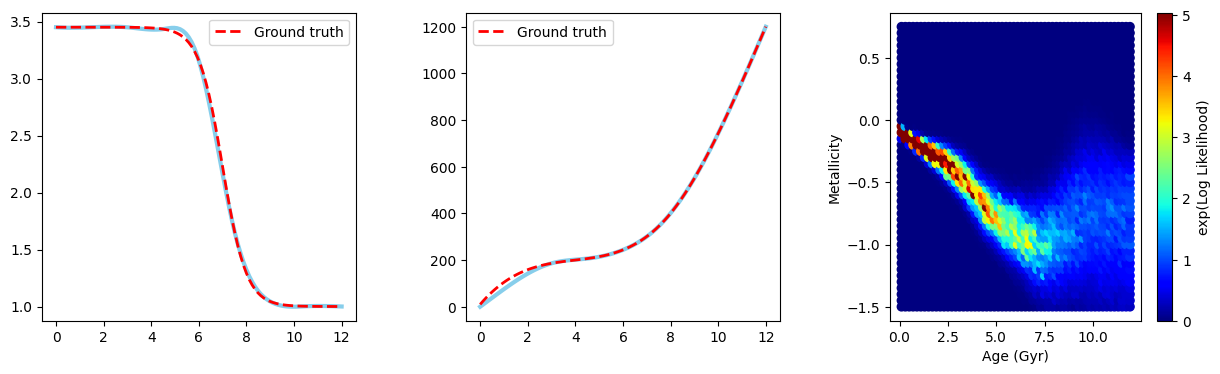

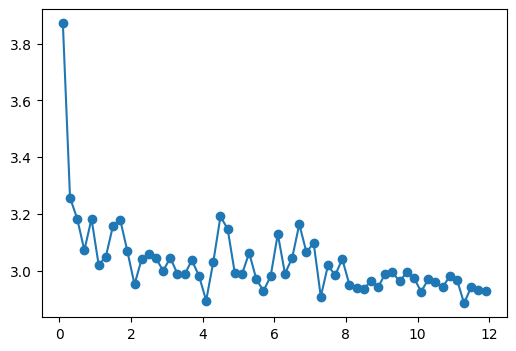

In [70]:

L_val = 10 * Vc0
Z_grid = jnp.arange(-1.5, 0.8, 0.05)
age_grid = jnp.arange(0.1, 12, 0.2)
log_age_grid = jnp.log10(age_grid)

Z_grid, log_age_grid = jnp.meshgrid(Z_grid, log_age_grid)
Z_grid = Z_grid.flatten()
log_age_grid = log_age_grid.flatten()

print('number of points in the grid:', len(Z_grid))

L_grid = jnp.ones_like(Z_grid) * L_val
sigmaZ_grid = jnp.ones_like(Z_grid) * 0.02 # Assuming a constant sigma_F for simplicity
sigma_logage_grid = jnp.ones_like(log_age_grid) * 0.02  # Assuming a constant sigma_logage for simplicity
sigmaLz_grid = jnp.ones_like(Z_grid) * 15  # Assuming a constant sigma_Lz for simplicity

# Generate samples
N_star = len(Z_grid)  # Number of stars in the grid
N_sample = int(1e4)
R_scale_for_sampling = 4
# F_centre_for_sampling, F_scale_for_sampling = -0.5,  0.5
F_centre_at_0, F_centre_at_12 = 0., -0.8
F_scale_at_0, F_scale_at_12 = 0.2, 0.8

jax_random_key1 = jax.random.PRNGKey(42)
jax_random_key2 = jax.random.PRNGKey(10086)
jax_random_key3 = jax.random.PRNGKey(10010)
jax_random_key4 = jax.random.PRNGKey(999)
jax_random_key5 = jax.random.PRNGKey(2025)
jax_random_key6 = jax.random.PRNGKey(124)
jax_random_key7 = jax.random.PRNGKey(456)
jax_random_key8 = jax.random.PRNGKey(789)


F_stack = jnp.repeat(Z_grid[None, :], N_sample, axis=0)
sigmaF_stack = jnp.repeat(sigmaZ_grid[None, :], N_sample, axis=0)
L_stack = jnp.repeat(L_grid[None, :], N_sample, axis=0)
sigmaL_stack = jnp.repeat(sigmaLz_grid[None, :], N_sample, axis=0)
logage_stack = jnp.repeat(log_age_grid[None, :], N_sample, axis=0)
sigmalogage_stack = jnp.repeat(sigma_logage_grid[None, :], N_sample, axis=0)

# L0_sample1 = jax.random.exponential(jax_random_key1, shape=(N_sample,N_star)) * (R_scale_for_sampling * Vc0) # * Lcentre
# L0_sample2 = jax.random.exponential(jax_random_key8, shape=(N_sample,N_star)) * (R_scale_for_sampling * Vc0) # * Lcentre
rng = np.random.default_rng(1234)
L0_sample1 = jnp.array(sample_x_exp(rng, R_scale_for_sampling * Vc0, size=(N_sample,N_star)))
rng = np.random.default_rng(5678)
L0_sample2 = jnp.array(sample_x_exp(rng, R_scale_for_sampling * Vc0, size=(N_sample,N_star)))

F_sample1 = jax.random.normal(jax_random_key2, shape=(N_sample,N_star)) * sigmaF_stack + F_stack
logage_sample1 = jax.random.normal(jax_random_key3, shape=(N_sample,N_star)) * sigmalogage_stack + logage_stack
L_sample1 = jax.random.normal(jax_random_key4, shape=(N_sample,N_star)) * sigmaL_stack + L_stack
# F_sample2 = jax.random.normal(jax_random_key5, shape=(N_sample,N_star)) * F_scale_for_sampling + F_centre_for_sampling  # Assuming a standard normal distribution for F
L_sample2 = jax.random.normal(jax_random_key6, shape=(N_sample,N_star)) * sigmaL_stack + L_stack
logage_sample2 = jax.random.normal(jax_random_key7, shape=(N_sample,N_star)) * sigmalogage_stack + logage_stack

age_sample1 = 10**(logage_sample1)
age_sample1 = jnp.where(age_sample1 > 15, 15, age_sample1)
age_sample2 = 10**(logage_sample2)
age_sample2 = jnp.where(age_sample2 > 15, 15, age_sample2)

F_centre_for_sampling = F_centre_at_0 + (F_centre_at_12 - F_centre_at_0)/12 * (age_sample2)
F_scale_for_sampling = F_scale_at_0 + (F_scale_at_12 - F_scale_at_0)/12 * (age_sample2)
F_sample2 = jax.random.normal(jax_random_key5, shape=(N_sample,N_star)) * F_scale_for_sampling + F_centre_for_sampling  # Assuming a standard normal distribution for F

logP_L0_num = XexpX_pdf_log(L0_sample1, R_scale_for_sampling * Vc0)
logP_L0_denom = XexpX_pdf_log(L0_sample2, R_scale_for_sampling * Vc0)
logP_F_denom = lnG(F_sample2, F_centre_for_sampling, F_scale_for_sampling)

data_test = {
    'L0_sample_num': L0_sample1,
    'L0_sample_denom': L0_sample2,
    'F_sample_num': F_sample1,
    'F_sample_denom': F_sample2,
    'age_sample_num': age_sample1,
    'age_sample_denom': age_sample2,
    'L_sample_num': L_sample1,
    'L_sample_denom': L_sample2,
    'logP_L_num': logP_L0_num,
    'logP_L_denom': logP_L0_denom,
    'logP_F_denom': logP_F_denom,
    'weights': jnp.ones(N_star)
}


age_pivot = np.array([0, 4, 8, 12, 20])
sigmaLz_pivot = np.array([10, 200, 400, 1200, 2000]) # sigma_Lz at 6 Gyr
sigmaLz_gt_interp = sp.interpolate.interp1d(age_pivot, sigmaLz_pivot, kind='cubic', fill_value='extrapolate', bounds_error=False)
Rd_gt = Rd_evolution_jump(np.linspace(0,15,100), Rdmax = 3.45, Rdmin = 1, tau_Rd = 7.0, delta_tau_Rd = 1.0)
Rd_gt_interp = sp.interpolate.interp1d(np.linspace(0,15,100), Rd_gt, kind='cubic', fill_value='extrapolate', bounds_error=False)

# aux_knots = jnp.linspace(0.,15.,Nknots)
aux_params = {}  # Auxiliary parameters for the model
aux_params['aux_knots'] = generate_aux_knots(Nknots=Nknots, age_max=12.)#jnp.linspace(0.,15.,Nknots)

ln_Rdisk_knots = jnp.log(Rd_gt_interp(aux_params['aux_knots']))  # Convert Rd to ln(Rdisk)
ln_sigmaLz_knots = jnp.log(sigmaLz_gt_interp(aux_params['aux_knots']))  # Convert sigma_Lz to ln(sigma_Lz)
# params_trial = {
#     'ln_Rdisk': ln_Rdisk_knots,
#     'ln_sigmaLz': ln_sigmaLz_knots,
# }

# params_trial = {'ln_Rdisk': jnp.array([ 1.0129285 ,  1.1170565 ,  1.1829929 ,  1.0032728 , -0.00879301,
#        -0.89356416,  0.7450388 ,  1.0250543 ]), 
#        'ln_sigmaLz': jnp.array([5.6591077, 3.8715577, 3.332939 , 4.028008 , 6.5052104, 6.417953 ,
#        6.1114144, 5.9913044])
#        }


# params_trial= {'ln_Rdisk': jnp.array([ 1.0166726 ,  1.0310085 ,  1.3933964 ,  0.7371091 , -0.90100026,
#         0.2041145 ,  0.08324957,  1.1941382 ]), 'ln_sigmaLz': jnp.array([4.0198526, 2.902585 , 5.4031043, 5.091751 , 5.7446647, 6.606856 ,
#        7.7502027, 5.8808165])}

fig, ax = plt.subplots(1, 3, figsize=(15, 4), gridspec_kw={'width_ratios': [1, 1, 1], 'wspace': 0.35})

# i = 852
# ln_Rdisk = np.array(results['ln_Rdisk'])
# ln_sigmaLz = np.array(results['ln_sigmaLz'])


# ln_Rdisk_i = ln_Rdisk[i]
# ln_sigmaLz_i = ln_sigmaLz[i]
# Rdiskinterp = InterpolatedUnivariateSpline(axu_knots, np.exp(ln_Rdisk_i), k=3)
# sigmaLzinterp = InterpolatedUnivariateSpline(axu_knots, np.exp(ln_sigmaLz_i) * axu_knots, k=3)
# ax[0].plot(np.linspace(0,12,100), Rdiskinterp(np.linspace(0,12,100)), ls = '-', lw = 3, alpha = 1, color='skyblue', rasterized=True)
# ax[1].plot(np.linspace(0,12,100), sigmaLzinterp(np.linspace(0,12,100)), ls = '-', lw = 3, alpha =1, color='skyblue', rasterized=True)

# check_mock = True
# print_ground_truth = check_mock
# if print_ground_truth:
#     Rdiskinterp = InterpolatedUnivariateSpline(aux_params['aux_knots'], np.exp(truth[:Nknots]), k=3)
#     ax[0].plot(np.linspace(0,12,100), Rd_gt_interp(np.linspace(0,12,100)), label='Ground truth', color='red', ls='--', lw = 2)
#     sigmaLzinterp = InterpolatedUnivariateSpline(aux_params['aux_knots'], np.exp(truth[Nknots:2*Nknots]), k=3)
#     ax[1].plot(np.linspace(0,12,100), sigmaLz_gt_interp(np.linspace(0,12,100)), label='Ground truth', color='red', ls='--', lw = 2)

# ax[0].legend()
# ax[1].legend()


# params_trial = {
#     # 'ln_Rdisk': jnp.array(ln_Rdisk[i]),
#     'ln_Rdisk': jnp.array(np.flip(np.linspace(-0.2, 1.2, Nknots))),
#     'ln_sigmaLz': jnp.array(ln_sigmaLz[i]),
# }

ln_Rdisk = np.array(ln_Rdisk_knots)
ln_sigmaLz = np.array(jnp.log(sigmaLz_gt_interp(aux_params['aux_knots']) / aux_params['aux_knots']))
ln_sigmaLz[0] = 4.
ln_sigmaLz[1] = 4.3
params_trial = {
    # 'ln_Rdisk': jnp.array(ln_Rdisk[i]),
    'ln_Rdisk': jnp.array(ln_Rdisk),
    'ln_sigmaLz': jnp.array(ln_sigmaLz),
}


time_start = time.perf_counter()
logL_numpyro_val = logL_numpyro(data_test, params_trial, **aux_params)
time_end = time.perf_counter()
print(f"time taken for logL_numpyro: {time_end - time_start:.4f} s")

Rdiskinterp = InterpolatedUnivariateSpline(axu_knots, np.exp(ln_Rdisk), k=3)
sigmaLzinterp = InterpolatedUnivariateSpline(axu_knots, np.exp(ln_sigmaLz) * axu_knots, k=3)
ax[0].plot(np.linspace(0,12,100), Rdiskinterp(np.linspace(0,12,100)), ls = '-', lw = 3, alpha = 1, color='skyblue', rasterized=True)
ax[1].plot(np.linspace(0,12,100), sigmaLzinterp(np.linspace(0,12,100)), ls = '-', lw = 3, alpha =1, color='skyblue', rasterized=True)

check_mock = True
print_ground_truth = check_mock
if print_ground_truth:
    Rdiskinterp = InterpolatedUnivariateSpline(aux_params['aux_knots'], np.exp(truth[:Nknots]), k=3)
    ax[0].plot(np.linspace(0,12,100), Rd_gt_interp(np.linspace(0,12,100)), label='Ground truth', color='red', ls='--', lw = 2)
    sigmaLzinterp = InterpolatedUnivariateSpline(aux_params['aux_knots'], np.exp(truth[Nknots:2*Nknots]), k=3)
    ax[1].plot(np.linspace(0,12,100), sigmaLz_gt_interp(np.linspace(0,12,100)), label='Ground truth', color='red', ls='--', lw = 2)

ax[0].legend()
ax[1].legend()



cb = ax[2].scatter(10**(log_age_grid), Z_grid, c=np.exp(logL_numpyro_val), cmap='jet', 
                vmin = np.percentile(np.exp(logL_numpyro_val), 5), vmax = np.percentile(np.exp(logL_numpyro_val), 99))
ax[2].set_xlabel('Age (Gyr)')
ax[2].set_ylabel('Metallicity')
# ax[2].set_xlim(12,0)
fig.colorbar(cb, ax=ax[2], label='exp(Log Likelihood)')

logage_unique = jnp.unique(log_age_grid)
ls = []
for i in range(len(logage_unique)):
    mask = log_age_grid == logage_unique[i]
    logL_numpyro_val_i = logL_numpyro_val[mask]
    ls.append(float(jsp.special.logsumexp(logL_numpyro_val_i)))

print(ls)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(10**logage_unique, ls, marker='o')

In [39]:
ln_sigmaLz

array([       inf, 4.50755381, 4.12716897, 3.82559357, 3.70393105,
       6.        , 4.11330347, 4.3946211 , 4.60517019, 4.82166176])